# 简介
之前的章节提到过在线策略算法的采样效率比较低，**我们通常更倾向于使用离线策略算法**。
- 然而，虽然 **DDPG 是离线策略算法，但是它的训练非常不稳定，收敛性较差，对超参数比较敏感，也难以适应不同的复杂环境**。

2018 年，一个更加稳定的离线策略算法 Soft Actor-Critic（SAC）被提出。

<font color="red">**SAC 的前身是 Soft Q-learning，它们都属于最大熵强化学习的范畴**。<font>

- Soft Q-learning 不存在一个显式的策略函数，而是使用一个Q函数的波尔兹曼分布，在连续空间下求解非常麻烦。
- <font color="green">**于是 SAC 提出使用一个 Actor 表示策略函数，从而解决这个问题。** <font>
    - **目前，在无模型的强化学习算法中，SAC 是一个非常高效的算法**，
    - 它学习一个随机性策略，在不少标准环境中取得了领先的成绩。

# 最大熵强化学习

#### 熵（entropy）**表示对一个随机变量的随机程度的度量。**

- 具体而言，如果X是一个随机变量，且它的概率密度函数为p，那么它的熵H就被定义为:
$H(X) = E_{x~p}[-logp(x)]$ 即X的随机程度

- <font color="red">在强化学习中，我们可以使用$H(π(·|s))$ **来表示策略π在状态s下的随机程度。**<font>


#### **最大熵强化学习（maximum entropy RL）** 的思想就是除了**要最大化累积奖励，还要使得策略更加随机**。

- <font color="red">如此，强化学习的**目标中**就**加入了一项熵的正则项**，定义为:<font>
$π^* = argmax_π{E_π{[\sum_t{r(s_t,a_t) +  αH(π(·|s_t))}]}} $ 
- α是一个正则化的系数，用来控制熵的重要程度

<font color="green">熵正则化增加了强化学习算法的**探索程度**:<font>
- α越大，探索性就越强，有助于加速后续的策略学习，**并减少策略陷入较差的局部最优的可能性**。

### 传统强化学习和最大熵强化学习的区别如图 14-1 所示。

In [1]:
from IPython.display import Image

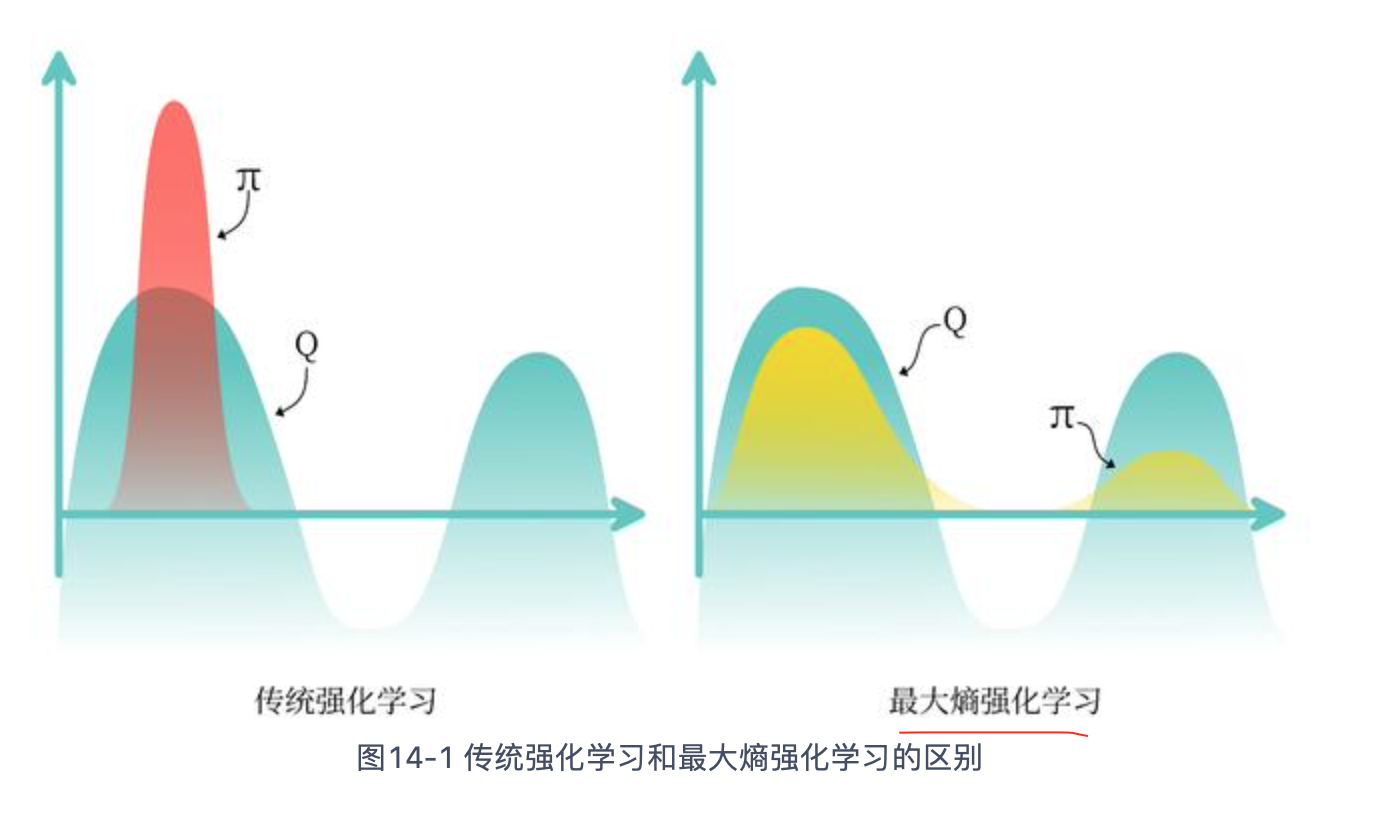

In [3]:
Image(filename='./image/entropy.png',width=500)

#### 左图：传统强化学习
- π（策略）：红色区域表示传统强化学习中的策略分布，它更倾向于选择具有更高价值的动作，即在给定状态下选择使预期回报最大化的动作。
- Q（价值函数）：棕色区域表示价值函数，它评估了在给定状态下采取某个动作的预期回报。
- 策略更新：在传统强化学习中，策略通常直接针对最大化预期回报进行优化，可能导致策略过于确定性，缺乏探索。

#### 右图：最大熵强化学习
- π（策略）：黄色区域表示最大熵强化学习中的策略分布，它不仅考虑了预期回报，还考虑了策略的熵，即策略的随机性或探索性。
- Q（价值函数）：与左图相同，蓝色区域表示价值函数。
- 策略更新：在最大熵强化学习中，策略更新不仅考虑最大化预期回报，还考虑最大化策略的熵。这样做可以鼓励探索，使策略更加多样化，有助于避免过早收敛到局部最优解。


##  Soft 策略迭代

在最大熵强化学习框架中，**由于目标函数发生了变化**，其他的一些定义也有相应的变化。

#### **首先，我们看一下 Soft 贝尔曼方程：**

$Q(s_t,a_t) = r(s_t,a_t) + γE_{s_{t+1}}[V(s_{t+1})]$

**其中状态价值函数被写为：**  

$V(s_t) = E_{{a_t} ∼ π}[Q(s_t,a_t) - alogπ(a_t|s_t)] = E_{{s_t} ∼ π}[Q(s_t,a_t)] + H(π(·|s_t))$
- $H(π(·|s_t) =  - logπ(a_t|s_t)$

于是，**根据该 Soft 贝尔曼方程，在有限的状态和动作空间情况下，Soft 策略评估可以收敛到策略π的 Soft Q函数**。

然后，根据如下 Soft 策略提升公式可以改进策略：



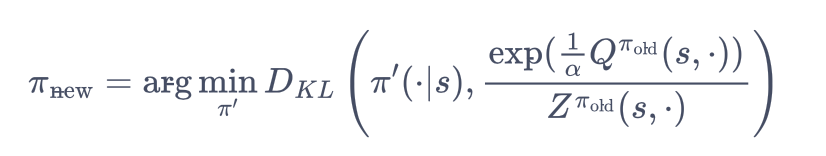

In [3]:
Image(filename='./image/soft_sac.png',width=600)

#### **重复交替使用 Soft 策略评估和 Soft 策略提升，最终策略可以收敛到最大熵强化学习目标中的最优策略。**

- 但该 Soft 策略迭代方法只适用于表格型（tabular）设置的情况，即状态空间和动作空间是有限的情况。
- <font color='red'>在连续空间下，我们需要通过参数化函数Q和策略π来近似这样的迭代。<font>

# SAC

在 SAC 算法中，我们有:
- 两个动作价值函数Q（参数分别为$w_1和w_2$）
- 和一个策略函数π（参数为θ）建模。

**基于 Double DQN 的思想，SAC 使用两个Q网络，但每次用Q网络时会挑选一个Q值小的网络，从而缓解Q值过高估计的问题。**

#### 任意一个函数的损失函数为：如下图
- $V(s_t) = E_{{a_t} ∼ π}[Q(s_t,a_t) - alogπ(a_t|s_t)] = E_{{s_t} ∼ π}[Q(s_t,a_t)] + H(π(·|s_t))$
- $H(π(·|s_t) =  - logπ(a_t|s_t)$

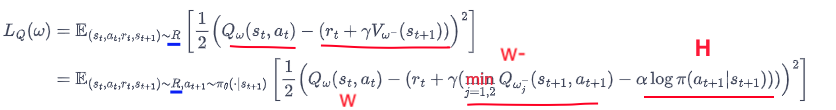

In [2]:
Image(filename='./image/sac_q_loss.png',width=700)

其中：
- **R**是策略过去收集的数据，因为 SAC 是一种离线策略算法。

- **为了让训练更加稳定，这里使用了目标Q网络$Q_{w^-}$，同样是两个目标Q网络，与两个Q网络一一对应。**

SAC 中目标Q网络的更新方式与 DDPG 中的更新方式一样。

#### 策略π的损失函数由 KL 散度得到，化简后为： 
- <font color='red'>**我们希望损失越小越好，-（损失） = 最大化V**<font>

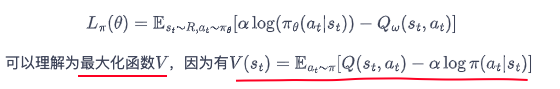

In [5]:
Image(filename='./image/policy_kl.png',width=600)

#### 对连续动作空间的环境
- **SAC 算法的策略输出高斯分布的均值和标准差，但是根据高斯分布来采样动作的过程是不可导的。因此，我们需要用到重参数化技巧**（reparameterization trick）。

- <font color='red'>重参数化的做法是先从一个单位高斯分布N采样，**再把采样值乘以标准差后加上均值**。<font>
  - **这样就可以认为是从策略高斯分布采样，并且这样对于策略函数是可导的**。
- 重参数化技巧是变分自编码器（VAE）和一些强化学习算法（例如策略梯度方法）中常用的技术，它允许模型通过可导的方式从随机分布中采样。

我们将其表示为$a_t = f_θ(ϵ_t;s_t)$
 - 其中$ϵ_t$个噪声随机变量。
   
#### 同时考虑到两个Q函数，重写策略的损失函数：（挑选两个Q网络中值小的那个）

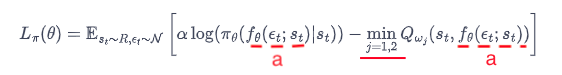

In [6]:
Image(filename='./image/sac_policy_loss.png',width=600)

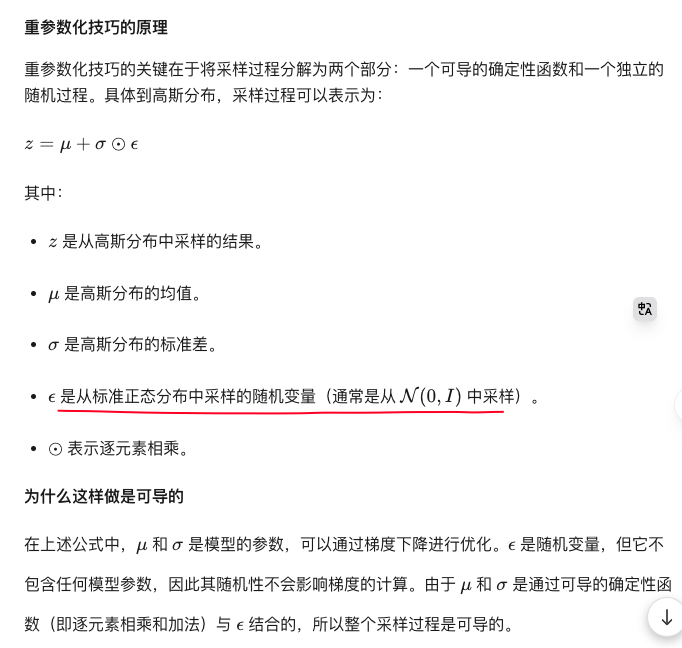

In [5]:
Image(filename='./image/Reparameterization.png')

##  自动调整熵正则项


<font color="red">在 SAC 算法中，如何选择熵正则项的系数α非常重要。<font>

#### 在不同的状态下需要不同大小的熵：
- 在最优动作**不确定**的某个状态下，熵的取值应该**大一点**,即熵的影响变大；
- 而在某个最优动作**比较确定**的状态下，熵的取值可以**小一点**，即熵的影响减小。

### **为了自动调整熵正则项，SAC 将强化学习的目标改写为一个带约束的优化问题：**


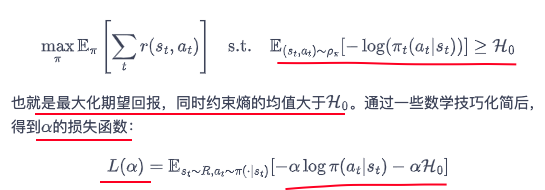

In [7]:
Image(filename='./image/entropy_auto.png')

- 即当策略的**熵低于** 目标值$H_0$时，**训练目标L(α)会使α的值增大**，进而在上述最小化损失函数$L_π{(θ)}$的过程中**增加了策略熵对应项的重要性**；

- 而当策略的**熵高于** 目标值$H_0$时，**训练目标L(α)会使α的值减小**，进而**使得策略训练时更专注于价值提升**。

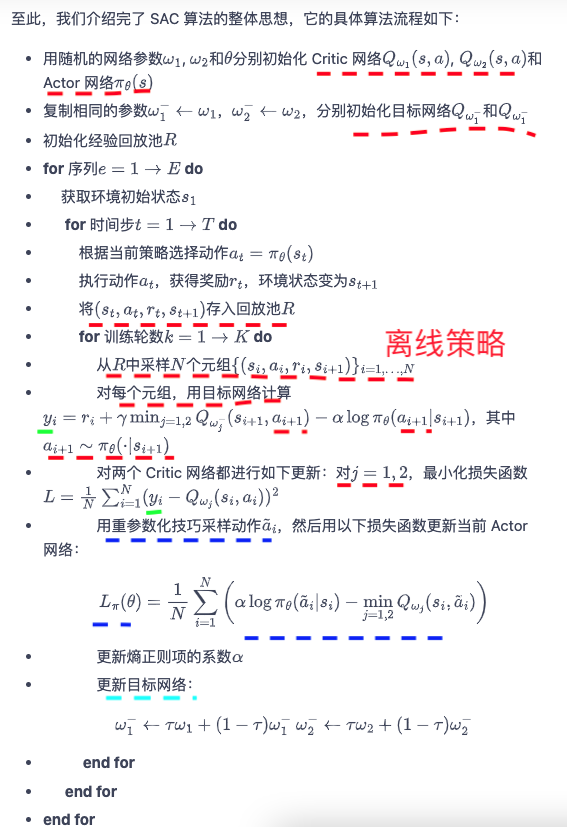

In [9]:
Image(filename='./image/sac_step.png',width=500)

#### **rsample() 方法是 PyTorch 中连续分布类的一个方法，用于从分布中采样。**

- 这个方法支持重参数化技巧（reparameterization trick），这是一种在变分推断和生成模型中常用的技术，它允许通过反向传播通过随机变量。


**重参数化技巧的关键在于，它允许你将采样过程分解为两部分：**
- 一个确定性的函数，该函数的输入是模型参数和噪声。
  - 它的输出是模型的预测或采样结果。
  - 这个函数是可导的，允许梯度通过它进行反向传播
- 一个随机过程，该过程生成噪声。通常是一个标准正态分布或其他简单分布。
  - 噪声的生成是完全随机的，不涉及任何模型参数。

<font color='red'>这样，当你需要计算梯度时，可以只对确定性部分进行反向传播，而随机过程不参与梯度计算。<font>

In [21]:
import torch

# 创建一个正态分布对象，均值为0，标准差为1
normal_dist = torch.distributions.Normal(loc=0., scale=1.)

# 使用 rsample() 方法从分布中采样
sample = normal_dist.rsample()
# 计算分布中某个值的对数概率密度
log_prob = normal_dist.log_prob(sample)

# torch.tanh 将正态分布的样本压缩到 [−1,1] 范围内，这通常用于确保动作值在特定的动作空间内
action = torch.tanh(sample)

# 打印采样结果
print("rsample():",sample)
print("log_prob():",log_prob)


print("action:",action)

rsample(): tensor(0.4765)
log_prob(): tensor(-1.0325)
action: tensor(0.4434)


### 调整对数概率

**log_prob = log_prob - torch.log(1 - torch.tanh(action).pow(2) + 1e-7)**


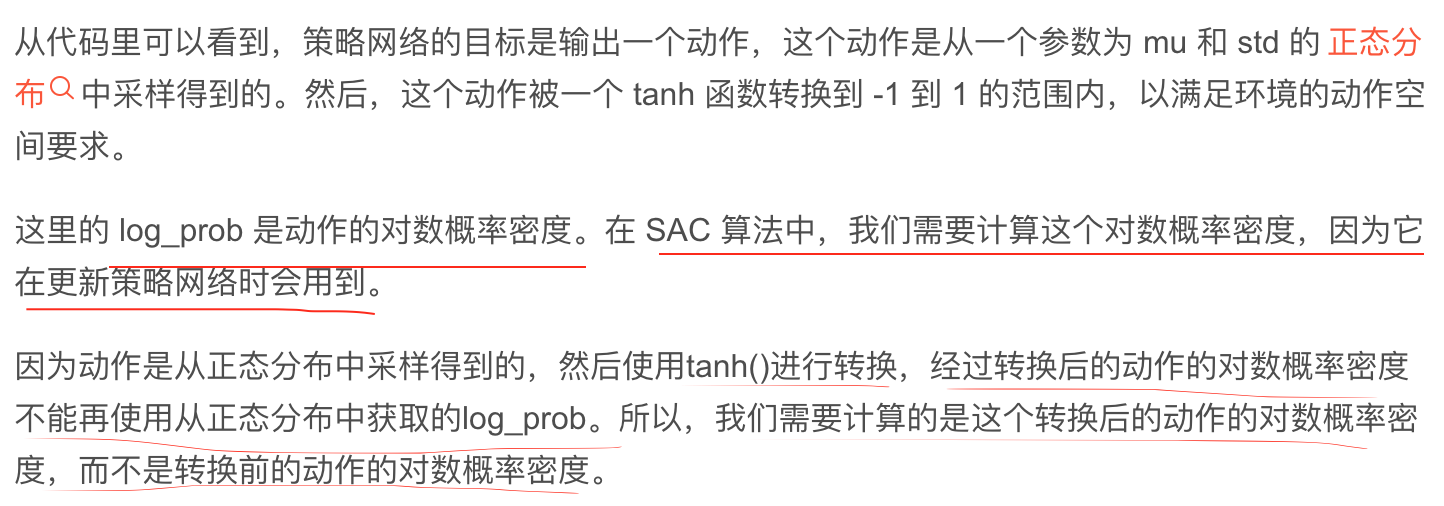

In [10]:
Image(filename='./image/tanh01.png',width=600)

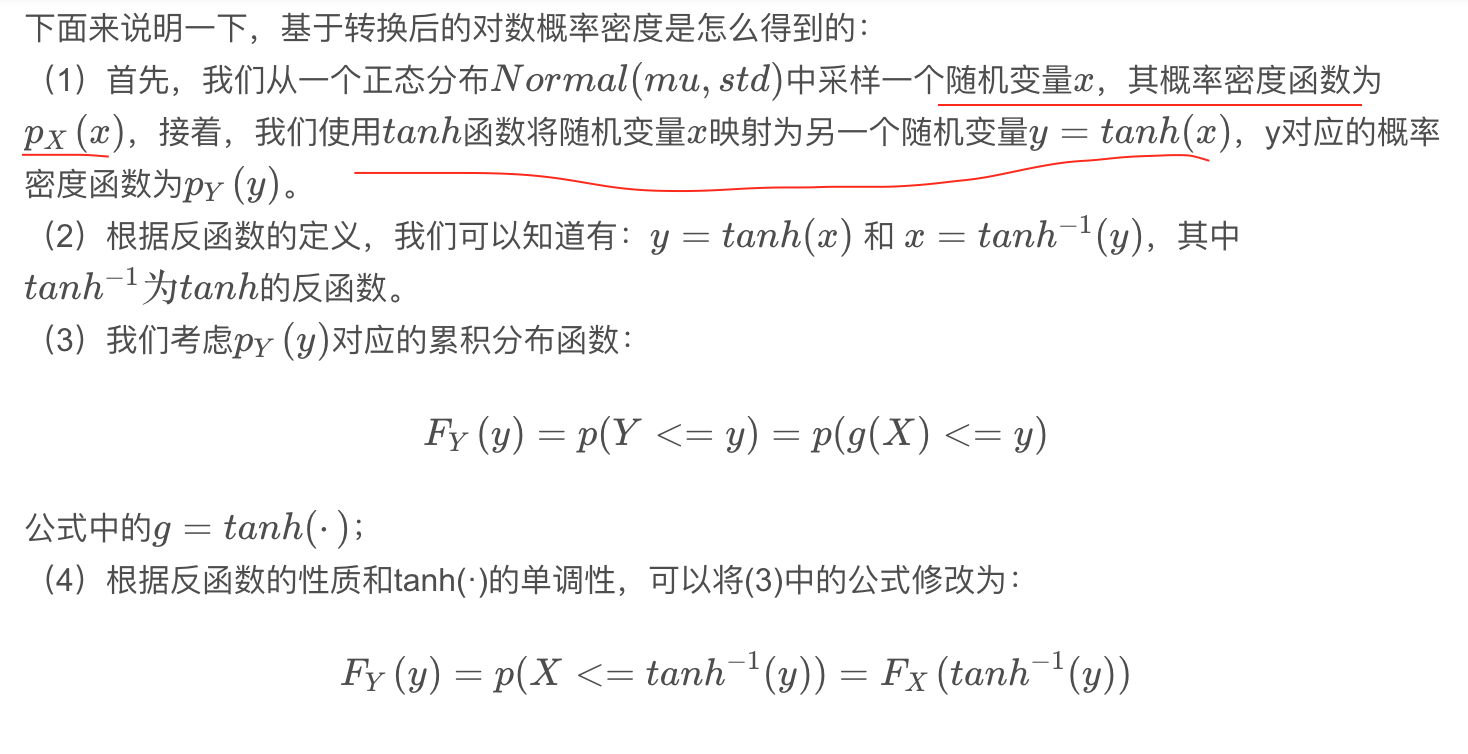

In [10]:
Image(filename='./image/tanh02.png',width=600)

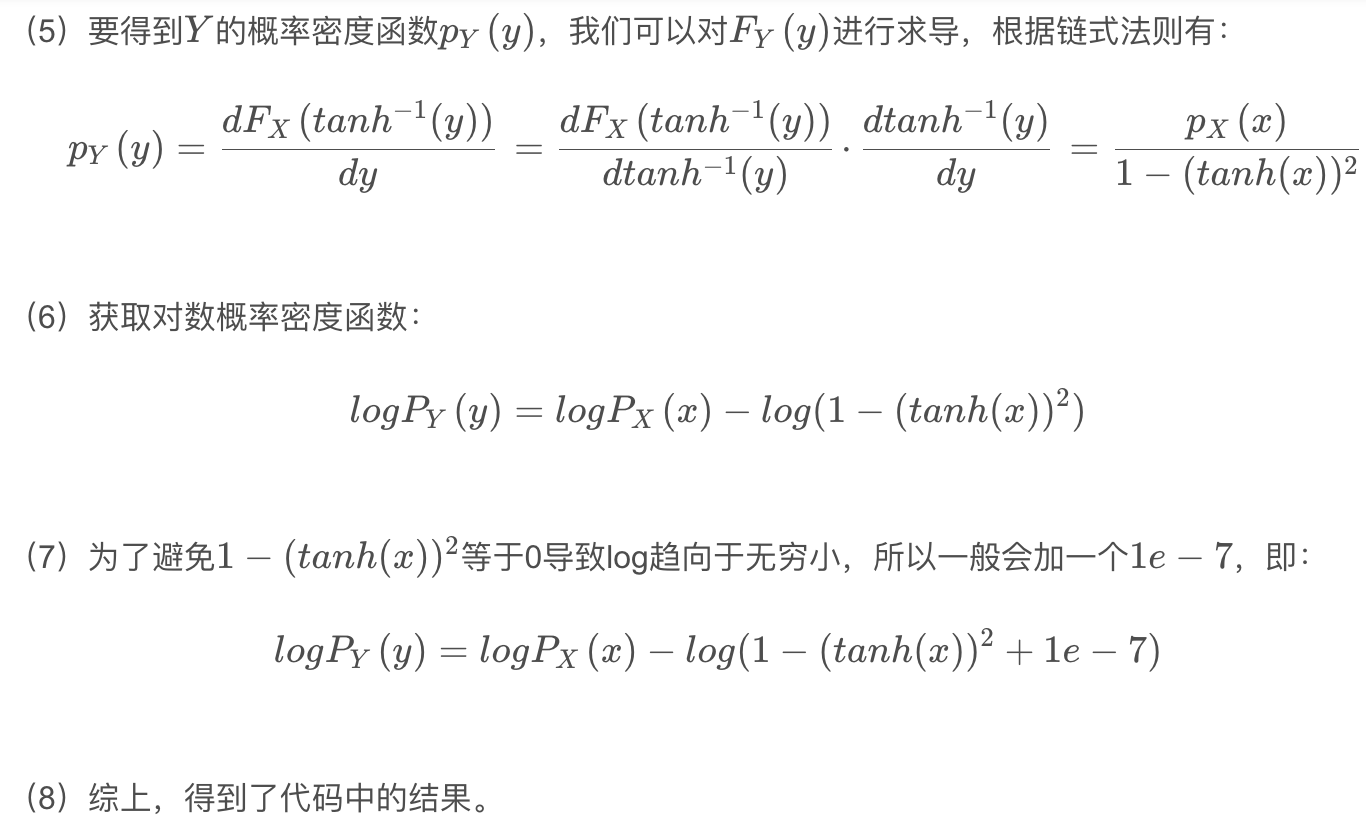

In [11]:
Image(filename='./image/tanh03.png',width=600)

In [29]:
import torch

# 创建两个示例张量
x = torch.randn(2, 3)  # 形状为 [2, 3]
a = torch.randn(2, 2)  # 形状为 [2, 2]

# 沿着第二个维度（dim=1）拼接它们
result = torch.concat([x, a], dim=1)

print("Tensor x:")
print(x)
print("\nTensor a:")
print(a)
print("\nConcatenated Tensor:")
print(result)

Tensor x:
tensor([[-0.6692,  0.2707,  0.1503],
        [-0.3468, -0.5909,  0.7861]])

Tensor a:
tensor([[0.9162, 0.7915],
        [0.4552, 1.1301]])

Concatenated Tensor:
tensor([[-0.6692,  0.2707,  0.1503,  0.9162,  0.7915],
        [-0.3468, -0.5909,  0.7861,  0.4552,  1.1301]])


# SAC 代码实践

首先在倒立摆环境下进行实验，然后再尝试将 SAC 应用到与离散动作交互的车杆环境。

In [13]:
import random
import gym
import numpy as np
from tqdm import tqdm
import torch
import torch.nn.functional as F
from torch.distributions import Normal
import matplotlib.pyplot as plt
import rl_utils

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


 ### **接下来定义 策略网络 和 价值网络 **
- 由于处理的是与连续动作交互的环境，
- **策略网络**输出一个**高斯分布的均值和标准差来表示的动作分布；**
- **价值网络**的输入是**状态和动作的拼接向量**，输出一个实数来表示动作价值。

In [30]:
class PolicyNetContinuous(torch.nn.Module):
    def __init__(self,state_dim,hidden_dim,action_dim,action_bound):
        super(PolicyNetContinuous,self).__init__()
        
        self.fc1 = torch.nn.Linear(state_dim,hidden_dim) # 共有层
        self.fc_mu = torch.nn.Linear(hidden_dim,action_dim) # 均值
        self.fc_std  = torch.nn.Linear(hidden_dim,action_dim) # 标准差
        
        self.action_bound = action_bound #action_bound是环境可以接受的动作最大值
        
    def forward(self,x):
        x = F.relu(self.fc1(x))
        mu = self.mu(x)
        std = F.softplus(self.fc_std(x))
        dist = Normal(mu,std)
        # 它允许在反向传播过程中通过梯度计算采样的均值和方差。这是为了解决采样过程中梯度消失的问题。
        # rsample()是重参数化采样
        normal_sample = dist.rsample(dist) 
        
        # log_prob 是在 normal_sample 处正态分布的对数概率密度
        log_prob = dist.log_prob(normal_sample)
        # torch.tanh 将正态分布的样本压缩到 [−1,1] 范围内，这通常用于确保动作值在特定的动作空间内。
        action = torch.tanh(normal_sample)
        
        # 计算tanh_normal分布的对数概率密度
        # 调整对数概率
        log_prob = log_prob - torch.log(1 - torch.tanh(action).pow(2) + 1e-7)
        # self.action_bound 是一个缩放因子，用于将动作值调整到实际的动作空间范围内。
        action = action * self.action_bound
        return action, log_prob
        
class  QvalueNetContinuous(torch.nn.Module):
    def __init__(self,state_dim,hidden_dim,action_dim):
        super(QvalueNetContinuous,self).__init__()
        # state_dim + action_dim
        self.fc1 = torch.nn.Linear(state_dim + action_dim,hidden_dim)
        self.fc2 = torch.nn.Linear(hidden_dim,hidden_dim)
        self.fc_out = torch.nn.Linear(hidden_dim,1)
    def forward(self,x,a):
        # dim =1 沿着第二个维度拼接他们
        cat = torch.concat([x,a],dim=1)
        x = F.relu(self.fc1(cat))
        x = F.relu(self.fc2(x))
        return self.fc_out(x)

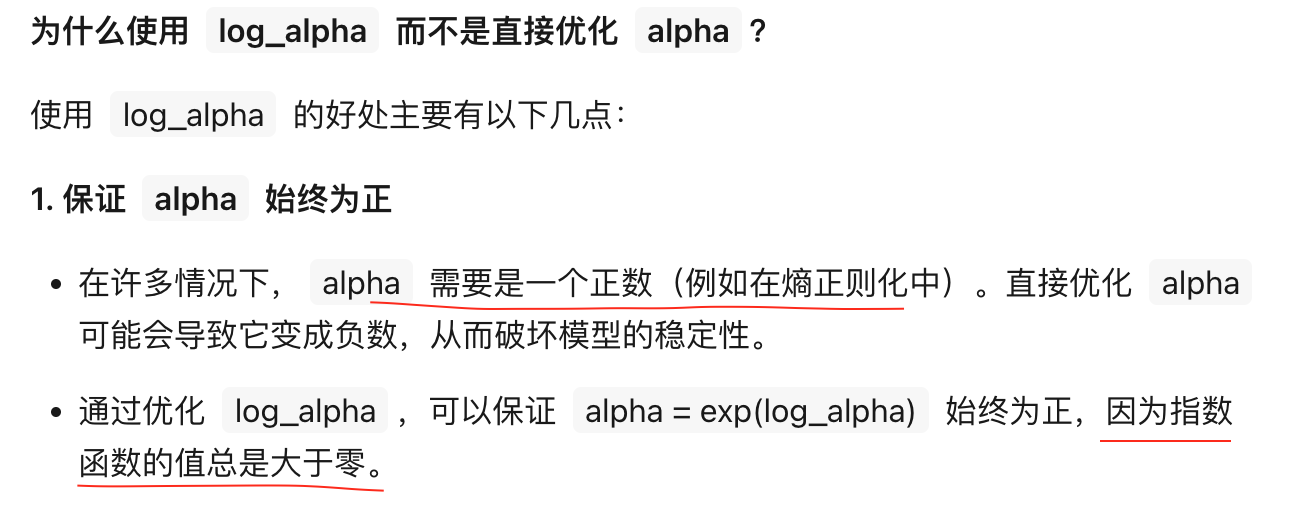

In [8]:
Image(filename='./image/alpha01.png',width=600)

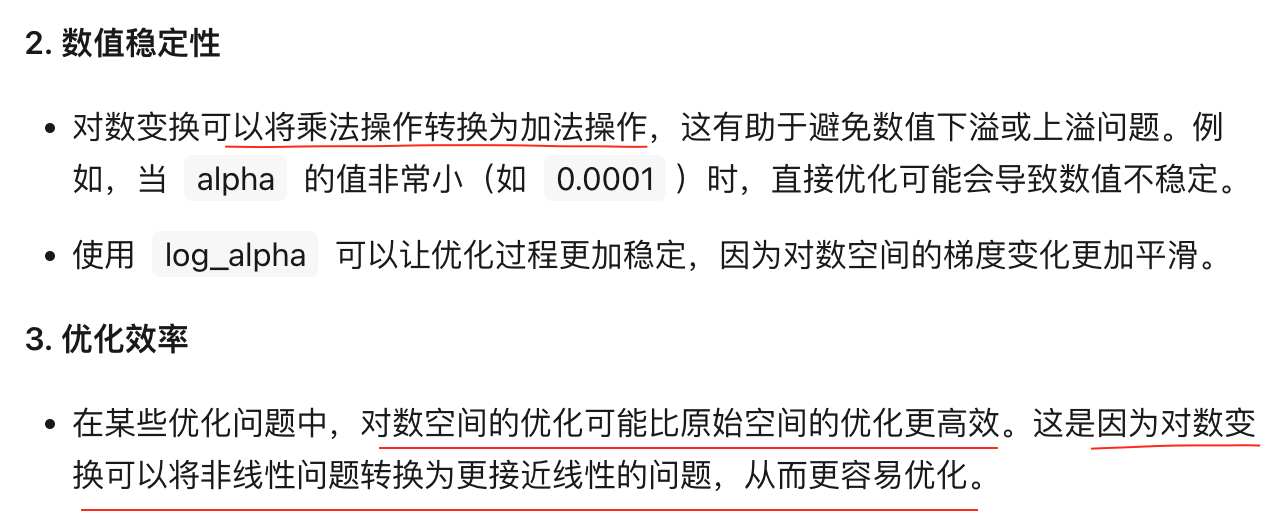

In [9]:
Image(filename='./image/alpha02.png',width=600)

### **然后我们来看一下 SAC 算法的主要代码。**

- 如 14.4 节所述，SAC 使用两个 Critic 网络$Q_{w_1}$和$Q_{w_2}$来使 Actor 的训练更稳定，
  - 而这两个 Critic 网络在训练时则各自需要一个目标价值网络。

- 因此，**SAC 算法一共用到 5 个网络，分别是一个策略网络、两个价值网络和两个目标价值网络。**

In [ ]:
''' 处理连续动作的SAC算法 '''
class SACContinuous:
     def __init__(self, state_dim, hidden_dim, action_dim, action_bound,
                 actor_lr, critic_lr, alpha_lr, target_entropy, tau, gamma,
                 device):
        self.actor = PolicyNetContinuous(state_dim, hidden_dim, action_dim,action_bound).to(device)  # 策略网络
        
        self.critic_1 = QValueNetContinuous(state_dim, hidden_dim,action_dim).to(device)  # 第一个Q网络
        self.critic_2 = QValueNetContinuous(state_dim, hidden_dim,action_dim).to(device)  # 第二个Q网络
        
        self.target_critic_1 = QValueNetContinuous(state_dim,hidden_dim, action_dim).to(device)  # 第一个目标Q网络
        self.target_critic_2 = QValueNetContinuous(state_dim,hidden_dim, action_dim).to(device)  # 第二个目标Q网络
        
        # 使目标Q网络的初始参数和Q网络一样
        self.target_critic_1.load_state_dict(self.critic_1.state_dict())
        self.target_critic_2.load_state_dict(self.critic_2.state_dict())
        
        
        self.actor_optimizer = torch.optim.Adam(self.actor.parameters(),lr=actor_lr)
        self.critic_1_optimizer = torch.optim.Adam(self.critic_1.parameters(),lr=critic_lr)
        self.critic_2_optimizer = torch.optim.Adam(self.critic_2.parameters(),lr=critic_lr)
        
        
        # 在 SAC 中，alpha 是熵的权重，用于平衡策略的熵和奖励。
        # 通过优化 log_alpha，可以动态调整熵的权重，从而实现更好的探索和利用平衡
        # 使用alpha的log值,可以使训练结果比较稳定
        self.log_alpha = torch.tensor(np.log(0.01), dtype=torch.float)
        self.log_alpha.requires_grad = True  # 可以对alpha求梯度
        self.log_alpha_optimizer = torch.optim.Adam([self.log_alpha],lr=alpha_lr)
        
        self.target_entropy = target_entropy  # 目标熵的大小
        self.gamma = gamma
        self.tau = tau
        self.device = device
        
    def take_action(self, state):
        state = torch.tensor([state], dtype=torch.float).to(self.device)
        action = self.actor(state)[0]
        return [action.item()]
    
    def soft_update(self, net, target_net):
        for param_target, param in zip(target_net.parameters(),net.parameters()):
            param_target.data.copy_(param_target.data * (1.0 - self.tau) + param.data * self.tau)
            
    # 计算目标Q值        
    def calc_target(self,rewards,next_states,dones):
        next_actions,log_prob = self.actor(next_states)
        entropy = -log_prob
        
        q1_value = self.target_critic_1(next_states,next_actions)
        q2_value = self.target_critic_2(next_states,next_actions)
        
        # q1_value和q2_value中小的那个
        next_value = torch.min(q1_value,q2_value) + self.log_alpha.exp() * entropy
        td_target = rewards + self.gamma * next_value * (1-dones)
        return td_target
    
    # 更新价值网络和策略网络
    def update(self,transition_dict):
        states = torch.tensor(transition_dict['states'],dtype=torch.float).to(self.device)
        actions = torch.tensor(transition_dict['actions'],dtype=torch.float).view(-1,1).to(self.device)
        rewards = torch.tensor(transition_dict['rewards'],dtype=torch.float).view(-1,1).to(self.device)
        next_states = torch.tensor(transition_dict['next_states'],dtype=torch.float).to(self.device)
        dones = torch.tensor(transition_dict['dones'],dtype=torch.float).view(-1,1).to(self.device)
        
        # 对倒立摆环境的奖励进行重塑以便训练
        rewards = (rewards + 8.0) / 8.0
        
        # 更新两个Q网络
        ta_target = self.calc_target(rewards,next_states,dones)
        
        critic_1_loss = torch.mean(F.mse_loss(self.critic_1(states,actions),td_target))
        critic_2_loss = torch.mean(F.mse_loss(self.critic_2(states,actions),td_target))
        
        self.critic_1_optimizer.zero_grad()
        critic_1_loss.backward()
        self.critic_1_optimizer.step()
        
        self.critic_2_optimizer.zero_grad()
        critic_2_loss.backward()
        self.critic_2_optimizer.step()
        
        # 更新策略网络
        new_actions,log_prob = self.actor(states)
        entropy = -log_prob
        
        q1_value = self.critic_1(states,new_actions)
        q2_value = self.critic_2(states,new_actions)
        actor_loss = torch.mean(-self.log_alpha.exp() * entropy - torch.min(q1_value,q2_value))
        
        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        self.actor_optimizer.step()
        
        # 更新alpha值
        alpha_loss = torch.mean((entropy - self.target_entropy).detach() * self.log_alpha.exp())
        self.log_alpha_optimizer.zero_grad()
        alpha_loss.backward()
        self.log_alpha_optimizer.step()
        
        self.soft_update(self.critic_1,self.target_critic_1)
        self.soft_update(self.critic_2,self.target_critic_2)

In [ ]:
env_name = 'Pendulum-v1'
env = gym.make(env_name)
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]
action_bound = env.action_space.high[0]  # 动作最大值
random.seed(0)
np.random.seed(0)
env.seed(0)
torch.manual_seed(0)

actor_lr = 3e-4
critic_lr = 3e-3
alpha_lr = 3e-4
num_episodes = 100
hidden_dim = 128
gamma = 0.99
tau = 0.005  # 软更新参数
buffer_size = 100000
minimal_size = 1000
batch_size = 64
target_entropy = -env.action_space.shape[0]
device = torch.device("cuda") if torch.cuda.is_available() else torch.device(
    "cpu")

replay_buffer = rl_utils.ReplayBuffer(buffer_size)
agent = SACContinuous(state_dim, hidden_dim, action_dim, action_bound,
                      actor_lr, critic_lr, alpha_lr, target_entropy, tau,
                      gamma, device)

return_list = rl_utils.train_off_policy_agent(env, agent, num_episodes,
                                              replay_buffer, minimal_size,
                                              batch_size)

In [ ]:
episodes_list = list(range(len(return_list)))
plt.plot(episodes_list, return_list)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('SAC on {}'.format(env_name))
plt.show()

mv_return = rl_utils.moving_average(return_list, 9)
plt.plot(episodes_list, mv_return)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('SAC on {}'.format(env_name))
plt.show()

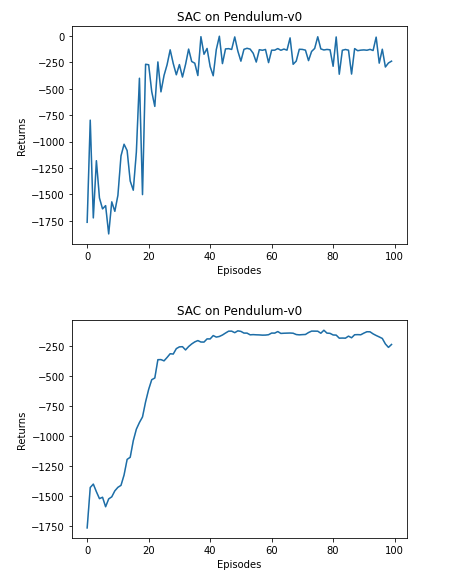

In [14]:
Image(filename='./image/sac_chart.png',width=600)

#### 可以发现，SAC 在倒立摆环境中的表现非常出色。

**SAC 算法原本是针对连续动作交互的环境提出的**，

那一个比较自然的问题便是：**SAC 能否处理与离散动作交互的环境呢？**

答案是肯定的，但是我们要做一些相应的修改。

#### <font color='red'>首先，策略网络和价值网络的网络结构将发生如下改变：<font>
- 策略网络的输出修改为在离散动作空间上的 softmax 分布；
- 价值网络直接接收状态和离散动作空间的分布作为输入。


In [ ]:
class PolicyNet(torch.nn.Module):
    def __init__(self, state_dim, hidden_dim, action_dim):
        super(PolicyNet, self).__init__()
        self.fc1 = torch.nn.Linear(state_dim, hidden_dim)
        self.fc2 = torch.nn.Linear(hidden_dim, action_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        # 策略网络的输出修改为在离散动作空间上的 softmax 分布
        return F.softmax(self.fc2(x), dim=1)


class QValueNet(torch.nn.Module):
    ''' 只有一层隐藏层的Q网络 '''
    def __init__(self, state_dim, hidden_dim, action_dim):
        super(QValueNet, self).__init__()
        self.fc1 = torch.nn.Linear(state_dim, hidden_dim)
        self.fc2 = torch.nn.Linear(hidden_dim, action_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        return self.fc2(x)

In [ ]:
''' 处理离散动作的SAC算法 '''
class SAC:
    def __init__(self, state_dim, hidden_dim, action_dim, actor_lr, critic_lr,
                 alpha_lr, target_entropy, tau, gamma, device):
        # 策略网络
        self.actor = PolicyNet(state_dim, hidden_dim, action_dim).to(device)
        # 第一个Q网络
        self.critic_1 = QValueNet(state_dim, hidden_dim, action_dim).to(device)
        # 第二个Q网络
        self.critic_2 = QValueNet(state_dim, hidden_dim, action_dim).to(device)
        
        self.target_critic_1 = QValueNet(state_dim, hidden_dim,action_dim).to(device)  # 第一个目标Q网络
        self.target_critic_2 = QValueNet(state_dim, hidden_dim,action_dim).to(device)  # 第二个目标Q网络
        
        # 使目标Q网络的初始参数和Q网络一样
        self.target_critic_1.load_state_dict(self.critic_1.state_dict())
        self.target_critic_2.load_state_dict(self.critic_2.state_dict())
        
        self.actor_optimizer = torch.optim.Adam(self.actor.parameters(),lr=actor_lr)
        self.critic_1_optimizer = torch.optim.Adam(self.critic_1.parameters(),lr=critic_lr)
        self.critic_2_optimizer = torch.optim.Adam(self.critic_2.parameters(),lr=critic_lr)
       
        # 使用alpha的log值,可以使训练结果比较稳定
        self.log_alpha = torch.tensor(np.log(0.01), dtype=torch.float)
        self.log_alpha.requires_grad = True  # 可以对alpha求梯度
        self.log_alpha_optimizer = torch.optim.Adam([self.log_alpha],lr=alpha_lr)
       
        self.target_entropy = target_entropy  # 目标熵的大小
        self.gamma = gamma
        self.tau = tau
        self.device = device

    def take_action(self, state):
        state = torch.tensor([state], dtype=torch.float).to(self.device)
        probs = self.actor(state)
        action_dist = torch.distributions.Categorical(probs)
        action = action_dist.sample()
        return action.item()

    # 计算目标Q值,直接用策略网络的输出概率进行期望计算
    def calc_target(self, rewards, next_states, dones):
        next_probs = self.actor(next_states)
        next_log_probs = torch.log(next_probs + 1e-8)
        entropy = -torch.sum(next_probs * next_log_probs, dim=1, keepdim=True)
       
        q1_value = self.target_critic_1(next_states)
        q2_value = self.target_critic_2(next_states)
        min_qvalue = torch.sum(next_probs * torch.min(q1_value, q2_value),
                               dim=1,
                               keepdim=True)
        next_value = min_qvalue + self.log_alpha.exp() * entropy
        td_target = rewards + self.gamma * next_value * (1 - dones)
        return td_target

    def soft_update(self, net, target_net):
        for param_target, param in zip(target_net.parameters(),
                                       net.parameters()):
            param_target.data.copy_(param_target.data * (1.0 - self.tau) +
                                    param.data * self.tau)

    def update(self, transition_dict):
        states = torch.tensor(transition_dict['states'],dtype=torch.float).to(self.device)
        actions = torch.tensor(transition_dict['actions']).view(-1, 1).to(self.device)  # 动作不再是float类型
        rewards = torch.tensor(transition_dict['rewards'],dtype=torch.float).view(-1, 1).to(self.device)
        next_states = torch.tensor(transition_dict['next_states'],dtype=torch.float).to(self.device)
        dones = torch.tensor(transition_dict['dones'],dtype=torch.float).view(-1, 1).to(self.device)

        # 更新两个Q网络
        td_target = self.calc_target(rewards, next_states, dones)
        critic_1_q_values = self.critic_1(states).gather(1, actions)
        critic_1_loss = torch.mean(
            F.mse_loss(critic_1_q_values, td_target.detach()))
        
        critic_2_q_values = self.critic_2(states).gather(1, actions)
        critic_2_loss = torch.mean(
            F.mse_loss(critic_2_q_values, td_target.detach()))
        
        self.critic_1_optimizer.zero_grad()
        critic_1_loss.backward()
        self.critic_1_optimizer.step()
       
        self.critic_2_optimizer.zero_grad()
        critic_2_loss.backward()
        self.critic_2_optimizer.step()

        # 更新策略网络
        probs = self.actor(states)
        log_probs = torch.log(probs + 1e-8)
        # 直接根据概率计算熵
        entropy = -torch.sum(probs * log_probs, dim=1, keepdim=True)  #
        q1_value = self.critic_1(states)
        q2_value = self.critic_2(states)
        min_qvalue = torch.sum(probs * torch.min(q1_value, q2_value),
                               dim=1,
                               keepdim=True)  # 直接根据概率计算期望
        actor_loss = torch.mean(-self.log_alpha.exp() * entropy - min_qvalue)
        
        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        self.actor_optimizer.step()

        # 更新alpha值
        alpha_loss = torch.mean(
            (entropy - target_entropy).detach() * self.log_alpha.exp())
        
        self.log_alpha_optimizer.zero_grad()
        alpha_loss.backward()
        self.log_alpha_optimizer.step()

        self.soft_update(self.critic_1, self.target_critic_1)
        self.soft_update(self.critic_2, self.target_critic_2)


In [ ]:
actor_lr = 1e-3
critic_lr = 1e-2
alpha_lr = 1e-2
num_episodes = 200
hidden_dim = 128
gamma = 0.98
tau = 0.005  # 软更新参数
buffer_size = 10000
minimal_size = 500
batch_size = 64
target_entropy = -1
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

env_name = 'CartPole-v1'
env = gym.make(env_name)
random.seed(0)
np.random.seed(0)
env.seed(0)
torch.manual_seed(0)
replay_buffer = rl_utils.ReplayBuffer(buffer_size)
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n
agent = SAC(state_dim, hidden_dim, action_dim, actor_lr, critic_lr, alpha_lr,
            target_entropy, tau, gamma, device)

return_list = rl_utils.train_off_policy_agent(env, agent, num_episodes,
                                              replay_buffer, minimal_size,
                                              batch_size)

In [ ]:
episodes_list = list(range(len(return_list)))
plt.plot(episodes_list, return_list)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('SAC on {}'.format(env_name))
plt.show()

mv_return = rl_utils.moving_average(return_list, 9)
plt.plot(episodes_list, mv_return)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('SAC on {}'.format(env_name))
plt.show()

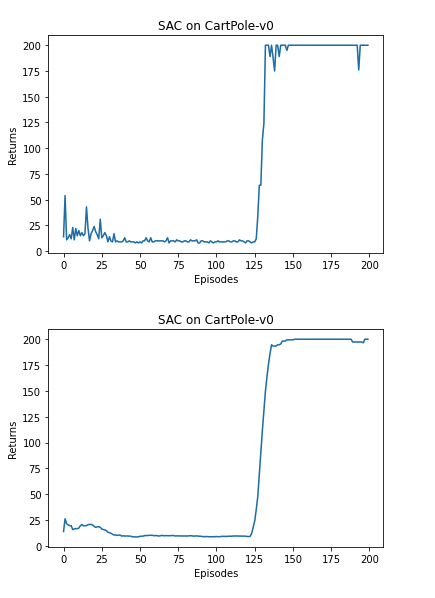

In [7]:
Image(filename='./image/sac2_chart.png',width=300)

可以发现，SAC 在离散动作环境车杆下具有完美的收敛性能，并且其策略回报的曲线十分稳定，**这体现出 SAC 可以在离散动作环境下平衡探索与利用的优秀性质。**

- 本章首先讲解了什么是最大熵强化学习，并通**过控制策略所采取动作的熵来调整探索与利用的平衡**，可以帮助读者加深对探索与利用的关系的理解；

- 然后讲解了 SAC 算法，剖析了它背后的原理以及具体的流程，

- 最后在连续的倒立摆环境以及离散的车杆环境中进行了 SAC 算法的代码实践。

**由于有扎实的理论基础和优秀的实验性能，SAC 算法已经成为炙手可热的深度强化学习算法，很多新的研究基于 SAC 算法，**

- 第 17 章将要介绍的基于模型的强化学习算法 MBPO 和
- 第 18 章将要介绍的离线强化学习算法 CQL 就是以 SAC 作为基本模块构建的。

# 参考文献
[1] HAARNOJA T, ZHOU A, ABBEEL P,et al. Soft actor-critic: Off-policy maximum entropy deep reinforcement learning with a stochastic actor [C] // International conference on machine learning, PMLR, 2018:1861-1870.

[2] HAARNOJA T, ZHOU A, HARTIKAINEN K, et al. Soft actor-critic algorithms and applications [J]. 2018.

[3] HAARNOJA T, TANG H, ABBEEL P,et al. Reinforcement learning with deep energy-based policies [C] // International conference on machine learning, PMLR, 2017:1352-1361.

[4] SCHULMAN J, CHEN X, ABBEEL P. Equivalence between policy gradients and soft q-learning [J]. 2017.